In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy

In [135]:
dataset = pd.read_csv("student-mat.csv")

In [122]:
dataset.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,pass
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,1
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,1
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,1


In [136]:
dataset.shape
dataset.info()
dataset.describe()
dataset.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [138]:
dataset["pass"] = (dataset["G3"] >= 10).astype(int)

In [139]:
dataset["pass"].value_counts()

pass
1    265
0    130
Name: count, dtype: int64

In [140]:
dataset["pass"].value_counts(normalize=True)*100

pass
1    67.088608
0    32.911392
Name: proportion, dtype: float64

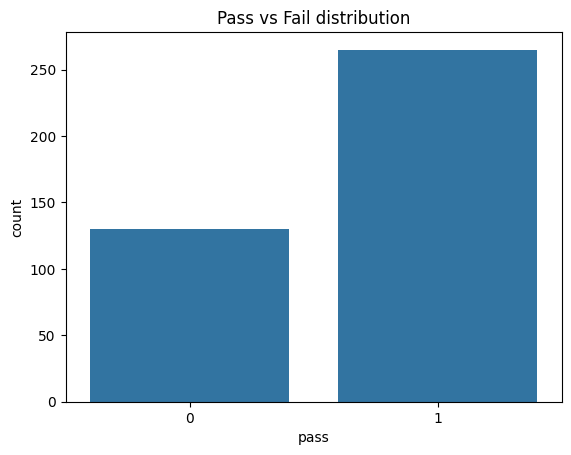

In [141]:
sns.countplot(x="pass",data=dataset)
plt.title("Pass vs Fail distribution")
plt.show()
          

In [142]:
numerical_cols=dataset.select_dtypes(include=['int64']).columns
categorical_cols=dataset.select_dtypes(include=['object']).columns

In [143]:
numerical_cols


Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3', 'pass'],
      dtype='object')

In [144]:
categorical_cols


Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')

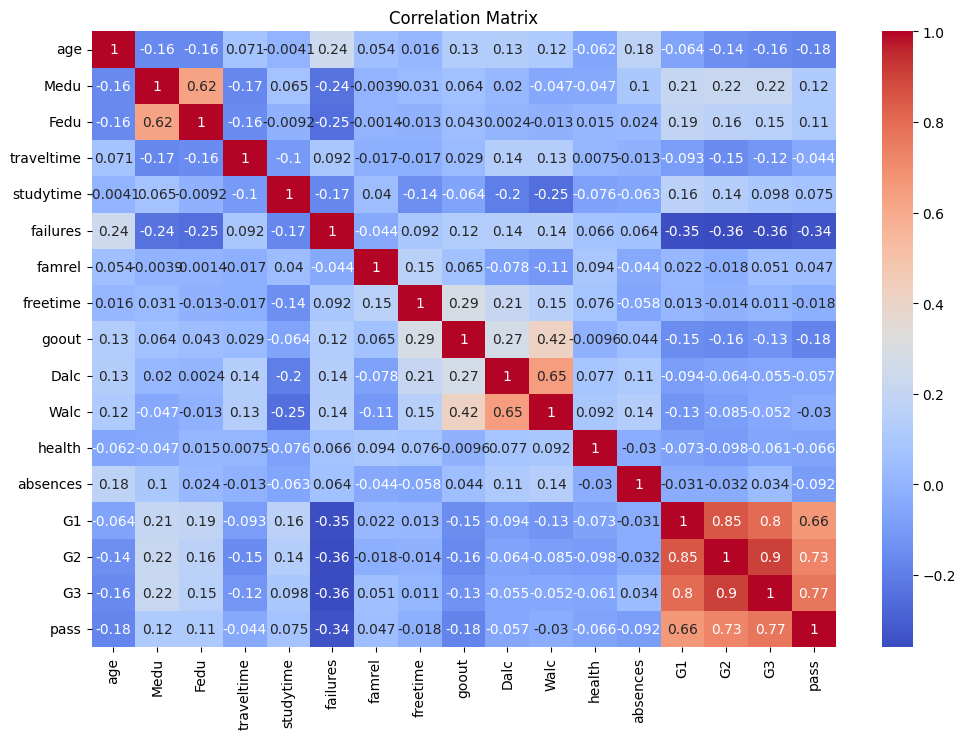

In [145]:
plt.figure(figsize=(12,8))
sns.heatmap(dataset[numerical_cols].corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [146]:
dataset = dataset.drop(["G1","G2","G3"], axis=1)

X = dataset.drop("pass", axis=1)
Y = dataset["pass"]

X = pd.get_dummies(X, drop_first=True)

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

X_train = X_train.to_numpy().astype(float)
X_test = X_test.to_numpy().astype(float)
Y_train = Y_train.to_numpy().astype(float)
Y_test = Y_test.to_numpy().astype(float)

In [147]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [148]:
def sigmoid(z):

    g=(1/(1+np.exp(-z)))
    return g
    

In [149]:
def compute_loss(X,Y,w,b):
    m=X.shape[0]
    sum1=0
    total_cost=0
    epsilon = 1e-8
    for i in range(m):
        slope=np.dot(X[i],w)+b
        fw=sigmoid(slope)
        loss=(-Y[i]*np.log(fw+epsilon))-((1-Y[i])*np.log(1-fw+epsilon))
        sum1+=loss
    total_cost=(1/m)*sum1
    return total_cost
        

In [150]:
def gradient(X,Y,w,b):
    m,n=X.shape
    dj_w=np.zeros((n,))
    dj_b=0
    for i in range(m):
        slope=np.dot(X[i],w)+b
        fw=sigmoid(slope)
        err=fw-Y[i]
        for j in range(n):
            dj_w[j]=dj_w[j]+err*X[i,j]
        dj_b=dj_b+err
    dj_w=(1/m)*dj_w
    dj_b=(1/m)*dj_b
    return dj_w,dj_b
    
        
    

In [151]:
def gradient_descent(X,Y,w_in,b_in,alpha,iterr):

    m,n=X.shape
    Jhistory=[]
    w=copy.deepcopy(w_in)
    b=b_in
    for i in range(iterr):
        dj_w,dj_b=gradient(X,Y,w,b)
        w=w-alpha*dj_w
        b=b-alpha*dj_b
        if i % 1000 == 0:
          
            print(compute_loss(X,Y,w,b))
    return w,b

In [152]:
w_tmp  = np.zeros(X_train.shape[1])
b_tmp  = 0
alph = 0.1
iters = 10000

w_out, b_out = gradient_descent(X_train, Y_train, w_tmp, b_tmp, alph, iters) 

0.6819902568616161
0.48292543769688323
0.48288736639207086
0.4828850495512417
0.48288489595000306
0.48288488558455706
0.48288488488167164
0.4828848848339299
0.4828848848306821
0.48288488483045966


In [153]:
def predict_prob(X,w,b):
    z=np.dot(X,w)+b
    return sigmoid(z)

In [154]:
def predict(X,w,b):
    probs=predict_prob(X,w,b)
    return (probs>=0.5).astype(int)

In [155]:
y_pred=predict(X_test,w_out,b_out)

In [156]:
print("Accuracy(%):",np.mean(y_pred==Y_test)*100)

Accuracy(%): 70.88607594936708


In [157]:
train_acc = np.mean(predict(X_train, w_out, b_out) == Y_train)
test_acc = np.mean(predict(X_test, w_out, b_out) == Y_test)

print("Train Accuracy(%):", train_acc*100)
print("Test Accuracy(%):", test_acc*100)

Train Accuracy(%): 75.9493670886076
Test Accuracy(%): 70.88607594936708
